In [1]:

import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.sparse import coo_matrix, csc_matrix
from numbers import Number
import numpy as np
import scipy
from scipy.sparse import csc_matrix, dia_matrix
from typing import Literal, Tuple, Callable, List
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import RectBivariateSpline
import linear_solver


np.set_printoptions(linewidth=np.inf)
np.set_printoptions(precision=3, suppress=True)

In [2]:
class NavierStokesSolver:
    
    scheme              : Literal["central_difference", "upwind", "hybrid"]

    L_x                 : float
    L_y                 : float
    L                   : float | None
    n_rows              : int
    n_cols              : int
    phi_B               : float
    gamma               : float
    error               : float
    
    # if u is None
    u_B                 : dict
    v_B                 : dict
    B                   : dict
    
    kinematic_viscosity : float
    mass_density        : float
    Re                  : float
    
    alpha_m             : float
    alpha_p             : float
    
    A                   : dict
    b                   : dict
    x                   : dict
    
    _constructor_args_  : dict
    
    A_diag              : dia_matrix
    
    def __init__(
        
        self, 
        scheme: Literal["central_difference", "upwind", "hybrid"] = "central_difference",
        L_x         : float = 1,
        L_y         : float = 1,
        L           : float | None = None,
        n_rows      : int = 50,
        n_cols      : int = 50,
        phi_Bw      : float = 100,
        phi_Be      : float = 0,
        phi_Bs      : float = 0,
        phi_Bn      : float = 100,
        gamma       : float = 1,
        u           : Tuple[Number | Callable] | None = None,
        
        # if u is None, we know to solve for a velocity field as well
        u_Bw        : float = 0,
        u_Be        : float = 0,
        u_Bs        : float = 0,
        u_Bn        : float = 1,
        v_Bw        : float = 0,
        v_Be        : float = 0,
        v_Bs        : float = 0,
        v_Bn        : float = 0,

        kinematic_viscosity : float = None,
        Re                  : float = 100,
        mass_density        : float = 1,
        alpha_m             : float = 0.8,
        alpha_p             : float = 0.3
        
        ):
        
        self._constructor_args_ = {key: val for key, val in locals().items() if key != 'self'}
        
        self.L_x        = L_x
        self.L_y        = L_y
        self.n_rows     = n_rows
        self.n_cols     = n_cols
        self.delta_x    = self.L_x / self.n_cols
        self.delta_y    = self.L_y / self.n_rows
        self.has_vel    = u is not None
        self.scheme     = scheme
        self.alpha_m    = alpha_m
        self.alpha_p    = alpha_p
        
        self.A = { '\phi': None, 'm': None, "p\'": None }
        self.b = { '\phi': None, 'u': None, 'v': None, "p\'": None }
        self.x = { '\phi': None, 'u': None, 'v': None, 'u_f': None, 'v_f': None, 's': None, "p\'": None,"p": None }
        self.A_diag = dia_matrix((self.n_rows * self.n_cols, self.n_rows * self.n_cols))

        self.u_B        = { 'n': u_Bn, 's': u_Bs, 'e': u_Be, 'w': u_Bw }
        self.v_B        = { 'n': v_Bn, 's': v_Bs, 'e': v_Be, 'w': v_Bw }
        self.phi_B      = { 'w': phi_Bw, 'e': phi_Be, 'n': phi_Bn, 's': phi_Bs }
        self.B          = { 'u': self.u_B, 'v': self.v_B, '\phi': self.phi_B }
        
        self.x['u_f']   = np.zeros((self.n_rows + 2, self.n_cols + 1))
        self.x['v_f']   = np.zeros((self.n_rows + 1, self.n_cols + 2))        
        self.x['u']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['v']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['s']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        
        self.gamma      = gamma
        
        if u is None: # We need to solve for velocity fields
            
            assert(L is not None)
            self.L      = L
            self.L_x    = L
            self.L_y    = L
            
            assert(bool(kinematic_viscosity) != bool(Re))
                    
            self.kinematic_viscosity    = kinematic_viscosity if kinematic_viscosity else u_Bn * L / Re
            self.mass_density           = mass_density
            self.Re                     = Re if Re else u_Bn * L / kinematic_viscosity
            self.gamma                  = 1/self.Re
            
            # set velocity boundary conditions
            
            self.x['u_f'][0, :]                 = self.B['u']['n']
            self.x['u_f'][self.n_rows + 1, :]   = self.B['u']['s']
            self.x['u_f'][:, self.n_cols]       = self.B['u']['e']
            self.x['u_f'][:, 0]                 = self.B['u']['w']
            
            self.x['v_f'][0, :]                 = self.B['v']['n']
            self.x['v_f'][self.n_rows, :]       = self.B['v']['s']
            self.x['v_f'][:, self.n_cols + 1]   = self.B['v']['e']
            self.x['v_f'][:, 0]                 = self.B['v']['w']
            
        else: # Use the known velocityy field to construct a matrix storing face velocities (giving convective link coefficients)
            
            uxf = lambda i, j : u[0] if isinstance(u[0], int) else u[0](j * self.delta_x, ((self.n_rows + 1) - i - 1)*self.delta_y)   
            uyf = lambda i, j : u[1] if isinstance(u[1], int) else u[1](j * self.delta_x, ((self.n_rows + 1) - i - 1)*self.delta_y) 
              
            for i in range(self.n_rows + 2):
                for j in range(self.n_cols+1):
                    self.x['u_f'][i,j] = uxf(i, j)
            for i in range(self.n_rows + 1):
                for j in range(self.n_cols + 2):
                    self.x['v_f'][i,j] = uyf(i, j)
            
            for i in range(1, self.n_rows+1):
                for j in range(1, self.n_cols + 1):
                    self.x['u'][i,j] = uxf(i+ self.delta_y, j + self.delta_x)
                    self.x['v'][i,j] = uyf(i+ self.delta_y, j + self.delta_x)
                    
            self.x['s'] = np.sqrt(self.x['u']**2 + self.x['v']**2)
                  
        # diffusive link coefficients
        self.D = {
            'w': self._area_('w') * self.gamma / self.delta_y,
            'e': self._area_('e') * self.gamma / self.delta_y,
            'n': self._area_('n') * self.gamma / self.delta_x,
            's': self._area_('s') * self.gamma / self.delta_x,
        }
        
        self.A['\phi'] = {
                'p': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'e': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'w': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                's': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'n': np.zeros((self.n_rows + 2, self.n_cols + 2)),
            }
        
        # set the solution boundary (Dirichlet)
        
        self.x['\phi']                                       = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['\phi'][0, 1: self.n_cols + 1]                = self.B['\phi']['n']
        self.x['\phi'][self.n_rows + 1, 1: self.n_cols + 1]  = self.B['\phi']['s']
        self.x['\phi'][:, self.n_cols + 1]                   = self.B['\phi']['e']
        self.x['\phi'][:, 0]                                 = self.B['\phi']['w']
        self.b['\phi']                                       = np.zeros((self.n_rows + 2,  self.n_cols + 2))

        if u is None: # Set the link_coefficient matrices and guess the solutions
            
            # guess the velocity field solution
            self.A['m'] = {
                'p': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'e': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'w': np.ones((self.n_rows + 2, self.n_cols + 2)),
                's': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'n': np.ones((self.n_rows + 2, self.n_cols + 2)),
            }
            self.A['p\''] = {
                'p': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'e': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'w': np.ones((self.n_rows + 2, self.n_cols + 2)),
                's': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'n': np.ones((self.n_rows + 2, self.n_cols + 2)),
            }

            self.x['p']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.x["p\'"]   = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            
            self.b['u']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.b['v']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.b["p\'"]   = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            
            # setting the solution boundary
            
            self.x['u'][0, 1: self.n_cols + 1]                      = self.B['u']['n']
            self.x['u'][self.n_rows +1, 1: self.n_cols + 1]         = self.B['u']['s']
            self.x['u'][:, self.n_cols + 1]                         = self.B['u']['e']
            self.x['u'][:, 0]                                       = self.B['u']['w']
            
            self.x['v'][0, 1:self.n_cols + 1]                       = self.B['v']['n']
            self.x['v'][self.n_rows + 1, 1: self.n_cols + 1]        = self.B['v']['s']
            self.x['v'][:, self.n_cols + 1]                         = self.B['v']['e']
            self.x['v'][:, 0]                                       = self.B['v']['w']
            
            # setting the pressure link coefficients

    def solve(self, objective: Literal['\phi', 'm'] ='\phi', solveSparse=True, tolerance=0.01, max_iter=10_000, threshold=1e-3):
        
        if objective == '\phi':
            self._construct_problem_(objective='\phi')
            return self._solve_jacobi_(objective='\phi', tolerance=tolerance, max_iter=max_iter) if not solveSparse else self._solve_sparse_(objective='\phi')

        # no velocity field given, must first solve three separate FVM problems
        # one for u, v and p
        # and only then can the problem for \phi

        err = np.inf
        i = 0
        while err > threshold:

            u_prev = self.x['u'].copy()
            v_prev = self.x['v'].copy()
            
            self._construct_problem_(objective='m')
            
            self._solve_sparse_(objective='u') if solveSparse else self._solve_jacobi_(objective='u', tolerance=tolerance, max_iter=max_iter)
            self._solve_sparse_(objective='v') if solveSparse else self._solve_jacobi_(objective='v', tolerance=tolerance, max_iter=max_iter)
            
            self._interp_face_v_()
            self._construct_problem_(objective="p\'")
            self._solve_sparse_(objective="p\'") if solveSparse else self._solve_jacobi_(objective='p\'', tolerance=tolerance, max_iter=max_iter)
            
            self._correct_p_()
            self._correct_cell_v_()
            self._correct_face_v_()
            
            self.x['s'] = np.sqrt(self.x['u']**2 + self.x['v']**2)
            
            p_err = np.linalg.norm(self.x["p\'"])
            u_err = np.linalg.norm(self.x['u'] - u_prev)
            v_err = np.linalg.norm(self.x['v'] - v_prev)
            
            err = u_err + v_err + p_err
            print(f"\rIteration: {i}, u_err: {u_err}, v_err: {v_err}, p_corr_err: {p_err}", sep='', end='')
            
            i+=1
        
        print(f"\nFinished with total error {err}")
        return self.x['u'], u_err, self.x['v'], v_err, self.x['p'], p_err
            
    def plot(self, 
             objective          : Literal['\phi', 'u', 'v', 'p']='\phi', 
             num_contours       : int = 40, 
             name               : str = None, 
             save               : bool = False,
             v_field_str        : Tuple[str, str] = None, 
             figsize            : int = 5,  
             num_streamlines    : int = 10
             ):
        
        core = self.x[objective][1:-1, 1:-1][::-1] if objective else None
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(2 * figsize if objective and num_streamlines else int(1.5 * figsize), figsize))
                    
        x_points = np.arange(0, self.n_cols)
        y_points = np.arange(0, self.n_rows)

        X, Y = np.meshgrid(x_points, y_points)
        
        u = self.x['u'][1:-1, 1:-1][::-1]
        v = self.x['v'][1:-1, 1:-1][::-1]
        
        if objective:
            assert(num_contours > 0)
            contour = ax.contourf(X, Y, core, levels=num_contours, cmap='jet' if not num_streamlines else 'bone')
            fig.colorbar(contour, ax=ax).ax.set_title(label=f'${objective}$')
                
            if num_streamlines:
                streamplot = plt.streamplot(X, Y, u, v, density=1.5, linewidth=1, color=np.sqrt(u**2 + v**2), arrowsize=1, cmap='jet')
                fig.colorbar(streamplot.lines, ax=ax).ax.set_title(label=f'$s$')
                
        else:
            assert(num_streamlines > 0)
            streamplot = plt.streamplot(X, Y, u, v, density=1.5, linewidth=1, color=np.sqrt(u**2 + v**2), arrowsize=1, cmap='jet')
            fig.colorbar(streamplot.lines, ax=ax).ax.set_title(label=f'$s$')
                        
        # Set axis ticks
        ax.set_xticks([0, self.n_cols-1])
        ax.set_xticklabels([0, self.L_x], rotation=0)
        ax.set_yticks([0, self.n_rows-1])
        ax.set_yticklabels([0, self.L_y], rotation=0)
        ax.set_ylim(ymin=0, ymax=self.n_rows-1)
        ax.set_xlim(xmin=0, xmax=self.n_cols-1)

        if objective in self.B.keys() and self.B[objective]:
            # TOP (in figure coordinates)
            ax.text(0.5, 1.05, f'${objective}_B = {self.B[objective]["n"]}$', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold') 

            # BOTTOM (in figure coordinates)
            ax.text(0.5, -0.05, f'${objective}_B = {self.B[objective]["s"]}$', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  

            # LEFT (in figure coordinates)
            ax.text(-0.05, 0.5, f'${objective}_B = {self.B[objective]["w"]}$', 
                    ha='center', va='center', rotation=90, transform=ax.transAxes, fontsize=12, weight='bold') 

            # RIGHT (in figure coordinates)
            ax.text(1.03, 0.5, f'${objective}_B = {self.B[objective]["e"]}$', 
                    ha='center', va='center', rotation=90, transform=ax.transAxes, fontsize=12, weight='bold') 


        if v_field_str:
            ax.text(0, -0.1, f'${{\\bf u}} = \\langle {v_field_str[0]}, {v_field_str[1]} \\rangle$' , 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  
        
        #Residual text (in figure coordinates)
        ax.text(1, -0.1, f'$L^2 Residual = {np.round(self.error, 4)}$', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  

        if save:
            plt.savefig(name, dpi=300, bbox_inches="tight")
        
        plt.show()

    def order_conv(self, exact_res: float = 320, coarse_res: float = 80, fine_res: float = 160, objective: Literal['\phi', 'uvp'] ='\phi') -> float:

        exact_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': exact_res, 'n_rows': exact_res})
        coarse_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': coarse_res, 'n_rows': coarse_res})
        fine_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': fine_res, 'n_rows': fine_res})
        
        if objective == '\phi':
            x_coarse, _ = coarse_solver.solve('\phi')
            x_fine, _ = fine_solver.solve('\phi')
            x_exact, _ = exact_solver.solve('\phi')
            return self._get_order_(x_coarse[1:-1, 1:-1], x_fine[1:-1, 1:-1], x_exact[1:-1, 1:-1], coarse_res, fine_res, exact_res)
        
        elif objective == 'uvp':
            x_coarses = coarse_solver.solve('m')
            x_fines = fine_solver.solve('m')
            x_exacts = exact_solver.solve('m')
            
            o = [None, None, None]
            for i in range(3):
                x_coarse = x_coarses[2*i]
                x_fine = x_fines[2*i]
                x_exact = x_exacts[2*i]
                o[i] = self._get_order_(x_coarse[1:-1, 1:-1], x_fine[1:-1, 1:-1], x_exact[1:-1, 1:-1], coarse_res, fine_res, exact_res)
            return o

    def _get_order_(self, x_coarse, x_fine, x_exact, coarse_res, fine_res, exact_res) -> float:
        
        linsp_coarse = np.linspace(0, 1, coarse_res)
        linsp_fine = np.linspace(0, 1, fine_res)
        linsp_exact = np.linspace(0, 1, exact_res)

        x_coarse_interpolator = RectBivariateSpline(linsp_coarse, linsp_coarse, x_coarse)

        x_coarse_interp = x_coarse_interpolator(linsp_exact, linsp_exact)

        x_fine_interpolator = RectBivariateSpline(linsp_fine, linsp_fine, x_fine)

        x_fine_interp = x_fine_interpolator(linsp_exact, linsp_exact)

        err_coarse = np.linalg.norm(x_exact - x_coarse_interp) / coarse_res
        err_fine = np.linalg.norm(x_exact - x_fine_interp) / fine_res

        O = (np.log(np.abs(err_coarse / err_fine))) / (np.log((1 / coarse_res) / (1 / fine_res)))
        
        return O

    def _construct_problem_(self, objective: Literal["\phi", "m", "p\'"] = "\phi"):

        if objective == 'p\'':
            self._p_corr_coeffs_()
            return
        
        b_e, b_w, b_n, b_s = None, None, None, None
        if self.scheme == "central_difference":
            b_e, b_w, b_n, b_s = self._scalar_coeff_cd_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
        elif self.scheme == 'upwind':
            b_e, b_w, b_n, b_s = self._scalar_coeff_upwind_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
        elif self.scheme == 'hybrid':
            b_e, b_w, b_n, b_s = self._scalar_coeff_hybrid_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
            
        if objective == '\phi':
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['\phi'], self.B['\phi'])
        else:
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['u'], self.B['u'])
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['v'], self.B['v'])
            
            self.b['u'][1:-1, 1:-1] -= self._p_src_('u')
            self.b['v'][1:-1, 1:-1] -= self._p_src_('v')
            
            self.A['m']['p'][1:-1, 1:-1] /= self.alpha_m
            self.b['u'][1:-1, 1:-1] += (1 - self.alpha_m) * self.A['m']['p'][1:-1, 1:-1] * self.x['u'][1:-1, 1:-1]
            self.b['v'][1:-1, 1:-1] += (1 - self.alpha_m) * self.A['m']['p'][1:-1, 1:-1] * self.x['v'][1:-1, 1:-1]
            
            
    def _p_src_(self, objective):

        
        if objective == "u":
            return  (1/2) * (self.x['p'][1:-1, 2:] - self.x['p'][1:-1, 0:-2]) * self._area_('e') 
                    
        elif objective == "v":
            return (1/2) * (self.x['p'][0:-2, 1:-1] - self.x['p'][2:, 1:-1]) * self._area_('n')
        
        
    def _set_arrays_(self, a_P, a_E, a_W, a_N, a_S, S_u, i, j, objective: Literal['\phi', 'm', 'p\'']='\phi'):
        
        self.A[objective]['p'][i, j] = np.float32(a_P)
        self.A[objective]['e'][i, j] = np.float32(a_E)
        self.A[objective]['w'][i, j] = np.float32(a_W)
        self.A[objective]['n'][i, j] = np.float32(a_N)
        self.A[objective]['s'][i, j] = np.float32(a_S)
              
        if objective != 'm':
            self.b[objective][i, j] = np.float32(S_u)
        else:
            self.b['u'][i, j] = np.float32(S_u[0])
            self.b['v'][i, j] = np.float32(S_u[1])
    
    
    def _to_sparse_(self, a_E, a_W, a_N, a_S, a_P):
        nrows, ncols = self.n_rows, self.n_cols
        num_cells = nrows * ncols

        # Flatten all coefficients
        a_P_flat = a_P[1:-1, 1:-1].flatten()  # Center
        a_E_flat = a_E[1:-1, 1:-1].flatten()  # East
        a_W_flat = a_W[1:-1, 1:-1].flatten()  # West
        a_N_flat = a_N[1:-1, 1:-1].flatten()  # North
        a_S_flat = a_S[1:-1, 1:-1].flatten()  # South

        # Set diagonals directly (matrix flipped along horizontal)
        self.A_diag.setdiag(a_P_flat, k=0)                # Main diagonal
        self.A_diag.setdiag(-a_E_flat[:-1], k=1)          # East diagonal
        self.A_diag.setdiag(-a_W_flat[1:], k=-1)          # West diagonal
        self.A_diag.setdiag(-a_N_flat[ncols:], k=-ncols)  # North diagonal (flipped matrix means the coeff is to the left)
        self.A_diag.setdiag(-a_S_flat[:-ncols], k=ncols)  # South diagonal (flipped matrix means the coeff is to the right)

        # Convert to CSC format for solver compatibility
        return self.A_diag.tocsc()    
    
    def _clear_a_diag(self):
        
        nrows, ncols = self.n_rows, self.n_cols
        num_cells = nrows * ncols
        self.A_diag.setdiag(0, k=0) 
        self.A_diag.setdiag(0, k=1)    
        self.A_diag.setdiag(0, k=-1)     
        self.A_diag.setdiag(0, k=-ncols)  
        self.A_diag.setdiag(0, k=ncols)
            
    def _solve_sparse_(self, objective: Literal["\phi", "m", "p\'"] = "\phi") -> Tuple[np.ndarray, float] :
        
        o = 'm' if objective in ['u', 'v'] else objective
        acsc = self._to_sparse_(
            a_E=self.A[o]['e'],
            a_W=self.A[o]['w'],
            a_N=self.A[o]['n'],
            a_S=self.A[o]['s'],
            a_P=self.A[o]['p']
            )
        bflat = self.b[objective][1:-1,1:-1].flatten()
        x, res = linear_solver.solve(acsc, bflat)
        #self._clear_a_diag()
        self.error = res
        
        self.x[objective][1:-1, 1:-1] = x.reshape((self.n_rows, self.n_cols))
            
        return x, res
    
    def _solve_jacobi_(self, objective: Literal["\phi", "u", "v", "p"] = "\phi", max_iter=10000, tolerance=1e-2) -> Tuple[np.ndarray, float]:
        
        # Start iterations for Jacobi method
        for it in range(max_iter):
            #x_prev = self.x[objective].copy()
            res = 0
            # Iterate over each cell in the domain
            for i in range(1, self.n_rows + 1): 
                for j in range(1, self.n_cols + 1):
                    # Update the value of \phi_P based on neighboring values
                    self.x[objective][i, j] = (self.A[objective]['e'][i, j] * self.x[objective][i, j+1] +
                                                self.A[objective]['w'][i, j] * self.x[objective][i, j-1] +
                                                self.A[objective]['n'][i, j] * self.x[objective][i-1, j] +
                                                self.A[objective]['s'][i, j] * self.x[objective][i+1, j] +
                                                self.b[objective][i, j]) / self.A[objective]['p'][i, j]
                    
            for i in range(1, self.n_rows + 1): 
                for j in range(1, self.n_cols + 1):
                    res += np.linalg.norm(self.x[objective][i,j] - (
                        self.A[objective]['e'][i, j] * self.x[objective][i, j+1] + 
                        self.A[objective]['w'][i, j] * self.x[objective][i, j-1] +
                        self.A[objective]['n'][i, j] * self.x[objective][i-1, j] +
                        self.A[objective]['s'][i, j] * self.x[objective][i+1, j] +
                        self.b[objective][i, j]) / self.A[objective]['p'][i, j]
                        )

            print(f"\rIter: {it}, res: {res}", sep='', end='')
            # Check for convergence
            if it > 0 and res < tolerance:
                break
                
        # Return the solution and residual
        self.error = res
        return self.x[objective], res          
                                                                                                                                                                                      
    def _p_corr_coeffs_(self):
        
        
        a_p = self.A['m']['p'][1:-1, 1:-1]
        a_n = self.A['m']['p'][:-2, 1:-1]
        a_s = self.A['m']['p'][2:, 1:-1]
        a_e = self.A['m']['p'][1:-1, 2:]
        a_w = self.A['m']['p'][1:-1, :-2]

        d_px = self._area_('e') / a_p
        d_py = self._area_('n') / a_p

        d_e = np.where(a_e, (1/2) * (self._area_('e') / a_e + d_px), 0)
        d_w = np.where(a_w, (1/2) * (self._area_('w') / a_w + d_px), 0)
        d_n = np.where(a_n, (1/2) * (self._area_('n') / a_n + d_py), 0)
        d_s = np.where(a_s, (1/2) * (self._area_('s') / a_s + d_py), 0)

        # Update A['p\''] matrices for 'e', 'w', 'n', 's'
        self.A['p\'']['e'][1:-1, 1:-1] = self.alpha_m * d_e * self._area_('e')
        self.A['p\'']['w'][1:-1, 1:-1] = self.alpha_m * d_w * self._area_('w')
        self.A['p\'']['n'][1:-1, 1:-1] = self.alpha_m * d_n * self._area_('n')
        self.A['p\'']['s'][1:-1, 1:-1] = self.alpha_m * d_s * self._area_('s')

        # Compute central coefficient (sum of neighbor coefficients)
        self.A['p\'']['p'][1:-1, 1:-1] = (
            self.A['p\'']['e'][1:-1, 1:-1]
            + self.A['p\'']['w'][1:-1, 1:-1]
            + self.A['p\'']['n'][1:-1, 1:-1]
            + self.A['p\'']['s'][1:-1, 1:-1]
        )

        # Compute b['p\''], dependent on face velocities
        uf_e = self.x['u_f'][1:-1, 1:]
        uf_w = self.x['u_f'][1:-1, :-1]
        uf_s = self.x['v_f'][1:, 1:-1]
        uf_n = self.x['v_f'][:-1, 1:-1]

        # =============================RHIE_CHOW_DEPENDENT================================ #
        self.b['p\''][1:-1, 1:-1] = (
            (uf_w * self._area_('w') - uf_e * self._area_('e'))
            + (uf_s * self._area_('s') - uf_n * self._area_('n'))
        )
        # =============================RHIE_CHOW_DEPENDENT================================ #


    def _scalar_coeff_cd_(self, A_p, A_e, A_w, A_n, A_s):
        
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')
        
        A_e[1:-1, 1:-2] =  self.D['e']      - (1/2) *   F_e[:, :-1]   
        A_e[1:-1, -2]   =  0
        b_e             =  2 * self.D['e']  -           F_e[:, -1]
        
        A_w[1:-1, 2:-1] =  self.D['w']      + (1/2) *   F_w[:, 1:]
        A_w[1:-1, 1]    =  0
        b_w             =  2 * self.D['w']  +           F_w[:, 0]   
        
        A_n[2:-1, 1:-1] =  self.D['n']      - (1/2) *   F_n[1:, :]
        A_n[1, 1:-1]    =  0
        b_n             =  2 * self.D['n']  -           F_n[0, :] 
        
        A_s[1:-2, 1:-1] =  self.D['s']      + (1/2) *   F_s[:-1, :]
        A_s[-2, 1:-1]   =  0
        b_s             =  2 * self.D['s']  +           F_s[-1, :]
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1]  + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s
        
        return b_e, b_w, b_n, b_s
        
        
    def _scalar_coeff_upwind_(self, A_p, A_e, A_w, A_n, A_s):
     
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')
        
        A_e[1:-1, 1:-2] =  self.D['e']          +   np.maximum(0, -F_e[:, :-1])   
        A_e[1:-1, -2]   =  0
        b_e             =  2 * self.D['e']      +   np.maximum(0, -F_e[:, -1])
        
        A_w[1:-1, 2:-1] =  self.D['w']          +   np.maximum(0, F_w[:, 1:])
        A_w[1:-1, 1]    =  0
        b_w             =  2 * self.D['w']      +   np.maximum(0, F_w[:, 0])
        
        A_n[2:-1, 1:-1] =  self.D['n']          +   np.maximum(0, -F_n[1:, :])
        A_n[1, 1:-1]    =  0
        b_n             =  2 * self.D['n']      +   np.maximum(0, -F_n[0, :])
        
        A_s[1:-2, 1:-1] =  self.D['s']          +   np.maximum(0, F_s[:-1, :])
        A_s[-2, 1:-1]   =  0
        b_s             =  2 * self.D['s']      +   np.maximum(0, F_s[-1, :])
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1] + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s
        
        return b_e, b_w, b_n, b_s

        
    
    def _scalar_coeff_hybrid_(self, A_p, A_e, A_w, A_n, A_s):
        
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')

        A_e[1:-1, 1:-2] = np.maximum(  self.D['e'] - (1/2) * F_e[:, :-1],  np.maximum(0, -F_e[:, :-1]))   
        A_e[1:-1, -2]   = 0
        b_e             = np.maximum(  2 * self.D['e']  - F_e[:, -1],      np.maximum(0, -F_e[:, -1]))
        
        A_w[1:-1, 2:-1] = np.maximum(  self.D['w'] + (1/2) * F_w[:, 1:],   np.maximum(0, F_w[:, 1:]))
        A_w[1:-1, 1]    = 0
        b_w             = np.maximum(  2 * self.D['w'] + F_w[:, 0],        np.maximum(0, F_w[:, 0]))
        
        A_n[2:-1, 1:-1] = np.maximum(  self.D['n'] - (1/2) * F_n[1:, :],   np.maximum(0, -F_n[1:, :])) 
        A_n[1, 1:-1]    = 0
        b_n             = np.maximum(   2 * self.D['n'] - F_n[0, :],       np.maximum(0, -F_n[0, :]))
        
        A_s[1:-2, 1:-1] = np.maximum( self.D['s'] + (1/2) * F_s[:-1, :],     np.maximum(0, F_s[:-1, :]))
        A_s[-2, 1:-1]   = 0
        b_s             = np.maximum(  2 * self.D['s'] + F_s[-1, :],         np.maximum(0, F_s[-1, :]))   
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1]  + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e                
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s 
        
        return b_e, b_w, b_n, b_s  
    
    def _scalar_src_(self, b_e, b_w, b_n, b_s, b, B):
        
        b[:, :]         =0
        b[1:-1, -2]     += b_e * B['e']
        b[1:-1, 1]      += b_w * B['w']
        b[1, 1:-1]      += b_n * B['n']
        b[-2, 1:-1]     += b_s * B['s']
       
                    
    def _interp_face_v_(self):
        
        
        a_e = self.A['m']['p'][1:-1, 2:-1]   # a_e at east face (skip ghost rows and east boundary)
        a_p = self.A['m']['p'][1:-1, 1:-2]  # a_p at cell center

        u_e = self.x['u'][1:-1, 2:-1]         # u_e at east face
        u_p = self.x['u'][1:-1, 1:-2]       # u_p at west face

        p_ee = self.x['p'][1:-1, 3:]        # Pressure two cells to the east
        p_e = self.x['p'][1:-1, 2:-1]       # Pressure at east face
        p_p = self.x['p'][1:-1, 1:-2]       # Pressure at current cell
        p_w = self.x['p'][1:-1, :-3]        # Pressure one cell to the west

        # Compute diffusivity factors
        d_e = (self._area_('e') / a_e) * self.alpha_m
        d_p = (self._area_('e') / a_p) * self.alpha_m

        # Compute u_f (interpolated velocity at the east face)
        self.x['u_f'][1:-1, 1:-1] = (
            (1 / 2) * (u_e + u_p)
            - (1 / 2) * (d_e + d_p) * (p_e - p_p)
            + (1 / 2) * d_p * ((1 / 2) * (p_e - p_w))
            + (1 / 2) * d_e * ((1 / 2) * (p_ee - p_p))
        )

        
        a_s = self.A['m']['p'][2:-1, 1:-1]     # a_s at south face (skip ghost row and bottom boundary)
        a_p = self.A['m']['p'][1:-2, 1:-1]   # a_p at cell center

        v_s = self.x['v'][2:-1, 1:-1]          # v_s at south face
        v_p = self.x['v'][1:-2, 1:-1]        # v_p at north face

        p_n = self.x['p'][:-3, 1:-1]         # Pressure one cell to the north
        p_p = self.x['p'][1:-2, 1:-1]        # Pressure at current cell
        p_s = self.x['p'][2:-1, 1:-1]          # Pressure at south face
        p_ss = self.x['p'][3:, 1:-1]         # Pressure two cells to the south

        # Compute diffusivity factors
        d_s = (self._area_('s') / a_s) * self.alpha_m
        d_p = (self._area_('s') / a_p) * self.alpha_m

        # Compute v_f (interpolated velocity at the south face)
        self.x['v_f'][1:-1, 1:-1] = (
            (1 / 2) * (v_s + v_p)
            - (1 / 2) * (d_s + d_p) * (p_p - p_s)
            + (1 / 2) * d_p * ((1 / 2) * (p_n - p_s))
            + (1 / 2) * d_s * ((1 / 2) * (p_p - p_ss))
        )
     
    def _correct_p_(self):
        
        self.x['p'] += self.alpha_p * self.x["p\'"]
        
        # neuman boundary with no pressure grad
        self._set_p_boundary_()
        
    def _set_p_boundary_(self):
        self.x['p'][0, 1: self.n_cols + 1]            = self.x['p'][1,  1: self.n_cols + 1] 
        self.x['p'][self.n_rows+1, 1:self.n_cols + 1] = self.x['p'][self.n_rows,  1: self.n_cols + 1]
        self.x['p'][1:self.n_rows+1, 0]               = self.x['p'][1:self.n_rows+1, 1]
        self.x['p'][1:self.n_rows+1, self.n_cols+1]   = self.x['p'][1:self.n_rows+1, self.n_cols]
        
    def _correct_cell_v_(self):
        
        a_p = self.A['m']['p'][1:-1, 1:-1]
        p_p = self.x['p\''][1:-1, 1:-1]
        p_w = self.x['p\''][1:-1, 0:-2]
        p_e = self.x['p\''][1:-1, 2:]
        p_s = self.x['p\''][2:, 1:-1]
        p_n = self.x['p\''][0:-2, 1:-1]
        
        d_p = self.alpha_m / a_p
        
        self.x['u'][1:-1, 1:-1] -= self._area_('w') * d_p * (1/2) * (p_e - p_w)
        self.x['v'][1:-1, 1:-1] -= self._area_('n') * d_p * (1/2) * (p_n - p_s)
        
    def _correct_face_v_(self):
   
        a_e = self.A['m']['p'][1:-1, 2:-1]  
        a_p = self.A['m']['p'][1:-1, 1:-2]

        p_e = self.x['p\''][1:-1, 2:-1]     
        p_p = self.x['p\''][1:-1, 1:-2] 
        
        d_p = (self._area_('e') * self.alpha_m / a_p) 
        d_e = (self._area_('e') * self.alpha_m / a_e) 

        self.x['u_f'][1:-1, 1:-1] -= (1/2) * (d_e + d_p) * (p_e - p_p)
            
  
        a_s = self.A['m']['p'][2:-1, 1:-1]
        a_p = self.A['m']['p'][1:-2, 1:-1]
        
        p_p = self.x['p\''][1:-2, 1:-1]     
        p_s = self.x['p\''][2:-1, 1:-1]
        
        d_p = (self._area_('s') * self.alpha_m / a_p) 
        d_s = (self._area_('s') * self.alpha_m / a_s) 

        self.x['v_f'][1:-1, 1:-1] -= (1/2) * (d_s + d_p) * (p_p - p_s)
        
            
    ########## HELPERS ###########  

        
    def _area_(self, face):
        if face == 'e' or face == 'w':
            return self.delta_y
        return self.delta_x

<>:81: SyntaxWarning: invalid escape sequence '\p'
<>:82: SyntaxWarning: invalid escape sequence '\p'
<>:83: SyntaxWarning: invalid escape sequence '\p'
<>:89: SyntaxWarning: invalid escape sequence '\p'
<>:152: SyntaxWarning: invalid escape sequence '\p'
<>:162: SyntaxWarning: invalid escape sequence '\p'
<>:163: SyntaxWarning: invalid escape sequence '\p'
<>:163: SyntaxWarning: invalid escape sequence '\p'
<>:164: SyntaxWarning: invalid escape sequence '\p'
<>:164: SyntaxWarning: invalid escape sequence '\p'
<>:165: SyntaxWarning: invalid escape sequence '\p'
<>:165: SyntaxWarning: invalid escape sequence '\p'
<>:166: SyntaxWarning: invalid escape sequence '\p'
<>:166: SyntaxWarning: invalid escape sequence '\p'
<>:167: SyntaxWarning: invalid escape sequence '\p'
<>:208: SyntaxWarning: invalid escape sequence '\p'
<>:208: SyntaxWarning: invalid escape sequence '\p'
<>:210: SyntaxWarning: invalid escape sequence '\p'
<>:211: SyntaxWarning: invalid escape sequence '\p'
<>:212: SyntaxWa

In [ ]:
s= NavierStokesSolver(u=None, L=1, n_cols=10, n_rows=10, Re=100, alpha_m=0.7, alpha_p=0.3, scheme='central_difference')
s.solve(objective='m', threshold=1e-4)

Iteration: 0, u_err: 1.1864998200089154, v_err: 0.17681504772930867, p_corr_err: 0.4365969065358828[[-0.053 -0.053 -0.028 -0.013 -0.004  0.001  0.005  0.011  0.02 ]
 [-0.017 -0.017 -0.017 -0.01  -0.004  0.002  0.007  0.013  0.021]
 [-0.002 -0.002 -0.007 -0.005 -0.001  0.003  0.007  0.012  0.018]
 [ 0.004  0.004 -0.    -0.001  0.001  0.004  0.007  0.01   0.014]
 [ 0.006  0.006  0.003  0.002  0.003  0.004  0.006  0.009  0.011]
 [ 0.006  0.006  0.004  0.003  0.003  0.004  0.006  0.007  0.008]
 [ 0.005  0.005  0.004  0.004  0.004  0.004  0.005  0.006  0.006]
 [ 0.004  0.004  0.004  0.003  0.003  0.004  0.004  0.004  0.005]
 [ 0.003  0.003  0.003  0.003  0.003  0.003  0.003  0.003  0.003]
 [ 0.002  0.002  0.002  0.002  0.002  0.002  0.002  0.002  0.002]]
[[-0.053 -0.053 -0.028 -0.013 -0.004  0.001  0.005  0.011  0.02 ]
 [-0.017 -0.017 -0.017 -0.01  -0.004  0.002  0.007  0.013  0.021]
 [-0.002 -0.002 -0.007 -0.005 -0.001  0.003  0.007  0.012  0.018]
 [ 0.004  0.004 -0.    -0.001  0.001  0.00

(array([[ 0.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  0.   ],
        [ 0.   ,  0.225,  0.278,  0.41 ,  0.514,  0.586,  0.637,  0.645,  0.618,  0.465,  0.341,  0.   ],
        [ 0.   , -0.042, -0.041,  0.034,  0.11 ,  0.175,  0.222,  0.235,  0.207,  0.108,  0.088,  0.   ],
        [ 0.   , -0.022, -0.042, -0.034, -0.012,  0.01 ,  0.021,  0.013, -0.012, -0.053, -0.013,  0.   ],
        [ 0.   , -0.011, -0.035, -0.057, -0.071, -0.084, -0.1  , -0.12 , -0.134, -0.126, -0.049,  0.   ],
        [ 0.   , -0.009, -0.038, -0.076, -0.11 , -0.141, -0.168, -0.186, -0.179, -0.137, -0.048,  0.   ],
        [ 0.   , -0.009, -0.04 , -0.085, -0.126, -0.161, -0.187, -0.193, -0.17 , -0.11 , -0.032,  0.   ],
        [ 0.   , -0.008, -0.038, -0.08 , -0.12 , -0.152, -0.17 , -0.167, -0.134, -0.074, -0.017,  0.   ],
        [ 0.   , -0.006, -0.03 , -0.065, -0.099, -0.125, -0.136, -0.127, -0.094, -0.044, -0.008,  0.   ],
        [ 0.   , -0.003, -0.019, -0.043, -0.06

: 

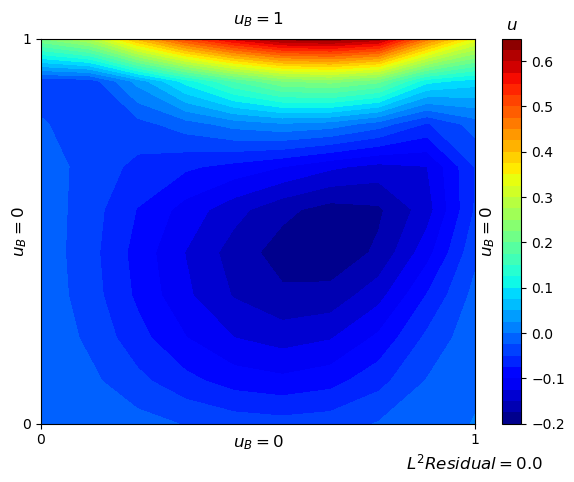

In [6]:
s.plot('u', num_streamlines=0)